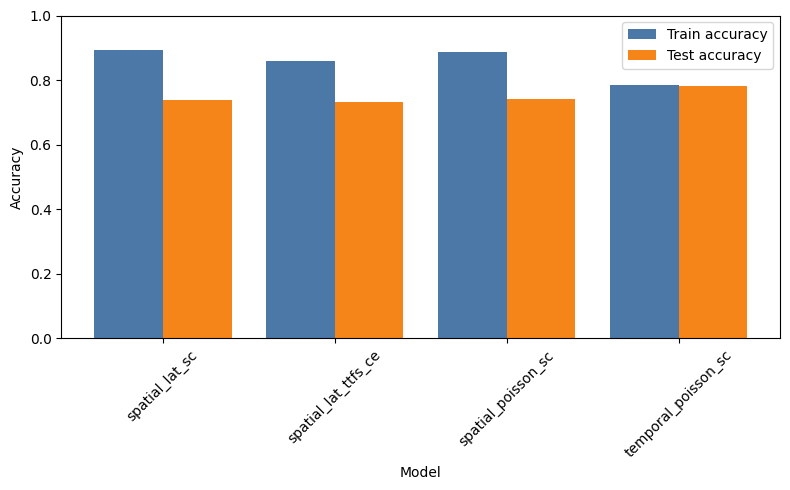

In [ ]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np

from colors import colors

files = sorted(glob('../output_results/E_sent/main/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

file_labels = []
train_accuracies = []
test_accuracies = []
for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    file_labels.append('_'.join([data.get('training_config', {}).get('input_mode'), data.get('training_config', {}).get('output_file_prefix') or 'poisson_sc']))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])

x = np.arange(len(files))
width = 0.4

fig, ax = plt.subplots(figsize=(max(8, len(files) * 1.2), 5))
ax.bar(x - width / 2, train_accuracies, width, label='Train accuracy', color=colors.accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test accuracy', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

../output_results/E_sent/main\lat_sc_2026-04-28_13-42-47_e-50_s-25_spatial.pt
Evaluation | split=test | samples=2085 | loss=0.8057 | acc=0.7396 | eval_time_ms=2512.00
Average AC operations per sample: 154698.66
Average energy per sample: 3964926.56 pJ (3964.9266 nJ)
2511.997800320387
../output_results/E_sent/main\lat_ttfs_ce_2026-04-28_13-58-26_e-50_s-25_spatial.pt
Evaluation | split=test | samples=2085 | loss=0.6648 | acc=0.7309 | eval_time_ms=2527.85
TTFS fallback rate: 0.0374
TTFS mean first spike time (fired output neurons): 21.4690
Average AC operations per sample: 180112.71
Average energy per sample: 4616288.52 pJ (4616.2885 nJ)
2527.8452998027205
../output_results/E_sent/main\sent_2026-04-28_10-13-09_e-50_s-25_spatial.pt
Evaluation | split=test | samples=2085 | loss=0.7099 | acc=0.7386 | eval_time_ms=2463.23
Average AC operations per sample: 1165145.84
Average energy per sample: 29862687.18 pJ (29862.6872 nJ)
2463.2255006581545
../output_results/E_sent/main\sent_2026-04-28_10-30

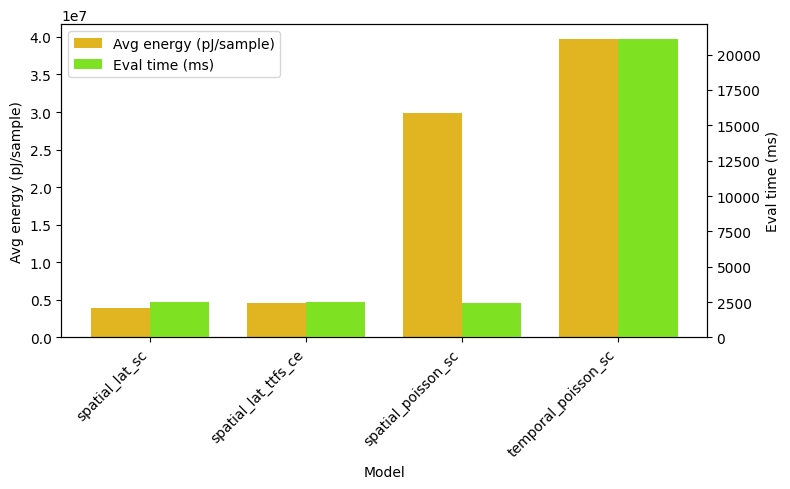

In [ ]:
from E_sent_eval import evaluate_model
from glob import glob
from pathlib import Path
import json
from argparse import Namespace

import matplotlib.pyplot as plt
import numpy as np
from experiments.colors import colors

models = sorted(glob('../output_results/E_sent/main/*.pt'))

labels = []
avg_energy_pj_per_sample = []
eval_time_ms = []

for model_path in models:
    meta_path = Path(model_path).with_suffix('.json')
    meta = json.loads(meta_path.read_text()).get('training_config', {})
    args = Namespace(**(meta | {
        "model_path": model_path,
        "diagnose": False,
        # "diagnose": True,
        # "limit": 10,
        "limit": None,
        "split": "test",
        "estimate_energy": True,
        "energy_ac_cost_pj": 25.63,
        "output_json": None,
    }))
    # Try to cast each number-like argument to int if possible, since JSON doesn't distinguish.
    args = Namespace(**{k: (int(v) if isinstance(v, str) and v.isdigit() else v) for k, v in vars(args).items()})
    print(model_path)
    results = evaluate_model(args)
    labels.append('_'.join([meta.get('input_mode'), meta.get('output_file_prefix') or 'poisson_sc']))
    avg_energy_pj_per_sample.append(results['avg_energy_pj_per_sample'])
    eval_time_ms.append(results.get('eval_time_ms', 0))
    print(results['eval_time_ms'])

positions = np.arange(len(labels))
width = 0.38

fig, ax1 = plt.subplots(figsize=(max(8, len(labels) * 1.2), 5))
ax2 = ax1.twinx()

bars_energy = ax1.bar(positions - width/2, avg_energy_pj_per_sample, width, color=colors.energy, label='Avg energy (pJ/sample)')
bars_time = ax2.bar(positions + width/2, eval_time_ms, width, color=colors.time, label='Eval time (ms)')

ax1.set_xlabel('Model')
ax1.set_ylabel('Avg energy (pJ/sample)')
ax2.set_ylabel('Eval time (ms)')
ax1.set_xticks(positions)
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.tick_params(axis='y')
ax2.tick_params(axis='y')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

TODO:
which has fastest inference time?
write up the sent analysis task methods